# Exploration of the Natural Earth Coastline data

In [1]:
import geopandas as gpd
from shapely.geometry import Point, box
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load coastline once
COASTLINE_DIR = "../datasets/coastline_dataset/ne_10m_coastline.shp"
coast = gpd.read_file(COASTLINE_DIR).to_crs("EPSG:5070")

## Visualization

In [13]:
def lonlat_bounds_to_proj(bounds, from_crs="EPSG:4326", to_crs="EPSG:5070"):
    minx, miny, maxx, maxy = bounds
    bbox = gpd.GeoSeries([box(minx, miny, maxx, maxy)], crs=from_crs)
    bbox_proj = bbox.to_crs(to_crs)
    return bbox_proj.total_bounds  # returns (minx, miny, maxx, maxy) in projected CRS

# plot the coastline given two points
def plot_coastline(bounds, ax=None):
    proj_bounds = lonlat_bounds_to_proj(bounds)
    if ax is None:
        fig, ax = plt.subplots()

    minx, miny, maxx, maxy = proj_bounds
    bbox_polygon = gpd.GeoSeries([box(minx, miny, maxx, maxy)], crs="EPSG:5070")

    # Clip the coastline to the bounding box
    clipped_coast = gpd.clip(coast, bbox_polygon)

    # Plot the clipped coastline
    clipped_coast.plot(ax=ax, color='blue')
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.title.set_text("US Coastline")
    return ax

<Axes: title={'center': 'US Coastline'}>

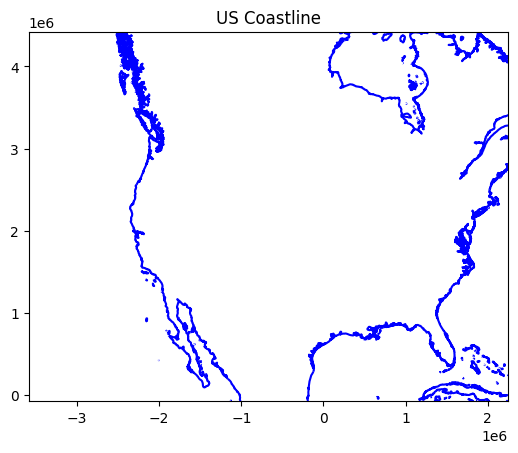

In [25]:
plot_coastline(bounds=(-130, 20, -75, 60))

## Coast distance from coords

In [3]:
def distance_to_sea(lat, lon):
    if np.isnan(lat) or np.isnan(lon):
        return np.nan
    
    point = gpd.GeoSeries(
        [Point(lon, lat)],
        crs="EPSG:4326"
    ).to_crs("EPSG:5070")

    return coast.distance(point.iloc[0]).min() / 1000  # km

In [4]:
distance_to_sea(lat=39.7392,lon=-104.9903)

np.float64(1200.25226368428)

## Add feats to the dataset

In [ ]:
# Define paths to the storm events CSV files
data_dir = Path('../datasets\\')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [13]:
df.drop(columns=[col for col in df.columns if col not in ['INDEX', 'BEGIN_LAT', 'BEGIN_LON']], inplace=True)
df.head()

,BEGIN_LAT,BEGIN_LON
0,34.94,-81.03
1,35.01,-80.93
2,35.64,-82.14
3,35.65,-84.18
4,35.87,-83.77


In [17]:
df['SEA_DISTANCE'] = np.nan
for idx, row in df.iterrows():
    df.loc[idx, 'SEA_DISTANCE'] = distance_to_sea(
        lat=row['BEGIN_LAT'],
        lon=row['BEGIN_LON'],
    )
    
df.head()

,BEGIN_LAT,BEGIN_LON,SEA_DISTANCE
0,34.94,-81.03,237.074753
1,35.01,-80.93,236.498569
2,35.64,-82.14,363.557791
3,35.65,-84.18,462.087891
4,35.87,-83.77,457.828037


In [18]:
df.drop(columns=['BEGIN_LAT', 'BEGIN_LON'], inplace=True)
df.to_csv(data_dir / 'disasters_new_feats' / 'sea_distance.csv', index=False)